In [ ]:
!pip install --upgrade transformers
!pip install git+https://github.com/huggingface/transformers.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 136.9 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-e9xyctx2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-e9xyctx2
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


In [ ]:
import torch
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from transformers import AutoModelForCausalLM, AutoTokenizer

sns.set_theme(style="whitegrid")

# Model IDs
m1_id = "Srikri7/qwen3.5-2b-reasoning"
m2_id = "Qwen/Qwen3.5-2B-Base"

def load_model(model_id):
    print(f"Loading {model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

    # Base models often don't have a pad token set by default
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True # Required for unmerged/bleeding-edge architectures
    )
    return model, tokenizer

print("Initializing models...")
m1, t1 = load_model(m1_id)
m2, t2 = load_model(m2_id)
print("Models loaded successfully!")

Initializing models...
Loading Srikri7/qwen3.5-2b-reasoning...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


...

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Models loaded successfully!


In [ ]:
# Raw Debugging Script - No Widgets
prompt = "A bat and a ball cost $1.10 in total. The bat costs $1.00 more than the ball. How much does the ball cost?"

print("="*50)
print(f"TESTING Srikri7 FINE-TUNE")
print("="*50)
try:
    res1 = generate_and_parse(m1, t1, prompt)
    print("THINKING:\n", res1['reasoning'])
    print("\nANSWER:\n", res1['answer'])
except Exception as e:
    print(f"CRASH ON MODEL 1: {e}")

print("\n" + "="*50)
print(f"TESTING QWEN BASE")
print("="*50)
try:
    res2 = generate_and_parse(m2, t2, prompt)
    print("THINKING:\n", res2['reasoning'])
    print("\nANSWER:\n", res2['answer'])
except Exception as e:
    print(f"CRASH ON MODEL 2: {e}")

TESTING Srikri7 FINE-TUNE
CRASH ON MODEL 1: name 'generate_and_parse' is not defined

TESTING QWEN BASE
CRASH ON MODEL 2: name 'generate_and_parse' is not defined


In [ ]:
import torch
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sns.set_theme(style="whitegrid")

def generate_adversarial(model, tokenizer, prompt):
    # THE TRAP: A multi-layered cognitive framework.
    # Base models usually fail to maintain this structure or hallucinate during the 'Critique' phase.
    system_instruction = (
        "You are an elite analytical engine. You MUST follow this exact cognitive framework, "
        "using the precise XML tags provided. Do not deviate.\n\n"
        "<think>\n"
        "<deconstruction> Break the problem down into its core, undeniable facts. </deconstruction>\n"
        "<hypothesis> Formulate an initial path to the solution. </hypothesis>\n"
        "<critique> Aggressively attack your hypothesis. What could be wrong? Where are the edge cases? </critique>\n"
        "<refinement> Finalize the logic based on your critique. </refinement>\n"
        "</think>\n"
        "<answer>\nProvide only the final, definitive solution here.\n</answer>"
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": prompt}
    ]

    # Apply chat template
    try:
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        text = f"System: {system_instruction}\nUser: {prompt}\nAssistant: "

    # Force the start of the framework
    if not text.endswith("<think>\n"):
         text += "<think>\n<deconstruction>"

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2048,
            temperature=0.7,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time

    generated_ids = outputs[0][len(inputs['input_ids'][0]):]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # --- Advanced Parsing ---
    reasoning_text = ""
    final_answer = ""

    # Try to split by the closing think tag first
    parts = full_response.split('</think>')
    if len(parts) > 1:
        reasoning_text = parts[0].strip()
        # Look for the answer tag in the remaining text
        ans_match = re.search(r'<answer>(.*?)</answer>', parts[1], re.DOTALL)
        final_answer = ans_match.group(1).strip() if ans_match else parts[1].strip()
    else:
        # The model failed the framework completely
        reasoning_text = full_response.strip()
        final_answer = "[FRAMEWORK FAILURE: Model did not close </think> tag]"

    # Telemetry
    reasoning_tokens = len(tokenizer.encode(reasoning_text)) if reasoning_text else 0
    answer_tokens = len(tokenizer.encode(final_answer)) if final_answer else 0
    total_tokens = reasoning_tokens + answer_tokens
    tps = total_tokens / gen_time if gen_time > 0 else 0

    return {
        "raw": full_response,
        "reasoning": reasoning_text,
        "answer": final_answer,
        "reasoning_toks": reasoning_tokens,
        "answer_toks": answer_tokens,
        "time": gen_time,
        "tps": tps
    }

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running Srikri7 Fine-Tune...
Running Qwen Base...

🧠 MODEL: Srikri7 Reasoning FT
THINKING PROCESS:
----------------------------------------
The problem involves three boxes, each labeled incorrectly. One box contains only apples, one contains only oranges, and one contains both apples and oranges. You can open one box, take out one fruit, and use that to correctly label all three boxes. </deconstruction>
<critique>
The solution must be:
1. Open the box labeled "apples and oranges"
2. Take out one fruit
3. Use the fruit to determine the contents of the other two boxes
4. Label all three boxes correctly
</critique>
<refinement>
The solution is:
1. Open the box labeled "apples and oranges"
2. Take out one fruit
3. If the fruit is an apple, then the box labeled "apples and oranges" actually contains only apples.
4. If the fruit is an orange, then the box labeled "apples and oranges" actually contains only oranges.
5. The box labeled "apples" must contain both apples and oranges (since it's

/tmp/ipykernel_2437/2408095940.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=[res_ft['tps'], res_base['tps']], ax=axes[1], palette=['#34495e', '#95a5a6'])


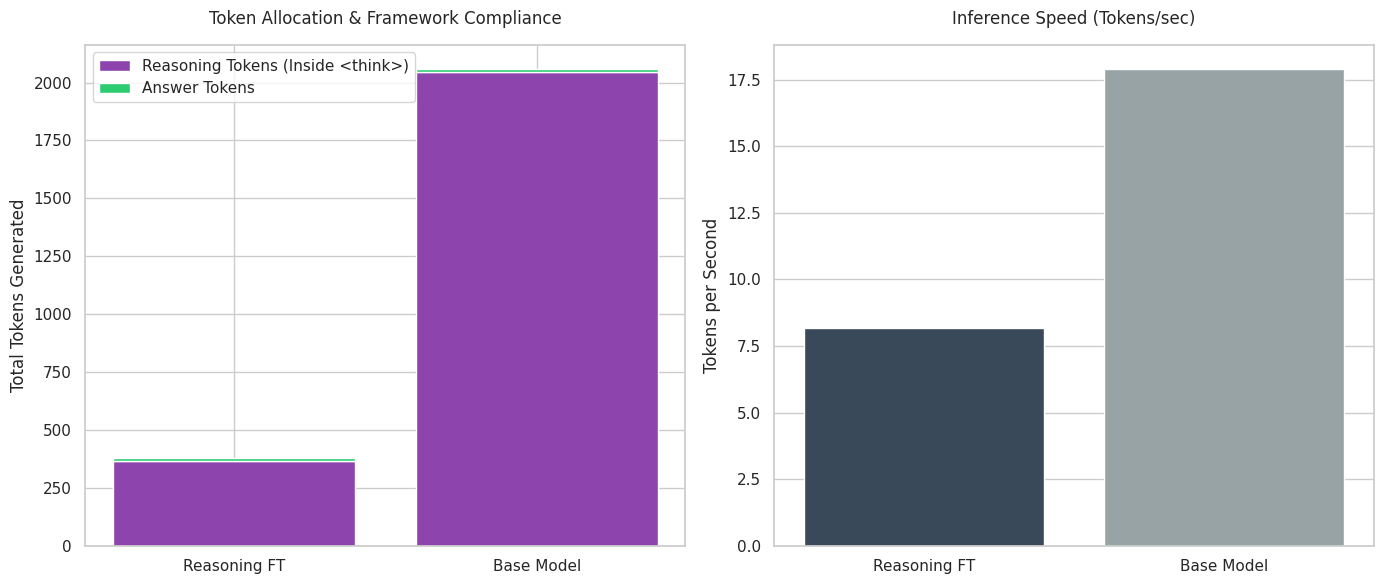

In [ ]:
# The Test Problem
test_prompt = (
    "There are three boxes. One contains only apples, one contains only oranges, "
    "and one contains both apples and oranges. All three boxes are labeled incorrectly. "
    "You are allowed to open just one box, take out exactly one piece of fruit, and look at it. "
    "How can you immediately label all of the boxes correctly?"
)

print("Running Srikri7 Fine-Tune...")
res_ft = generate_adversarial(m1, t1, test_prompt)

print("Running Qwen Base...")
res_base = generate_adversarial(m2, t2, test_prompt)

# --- 1. Terminal Output Dump ---
for name, res in [("Srikri7 Reasoning FT", res_ft), ("Qwen Base Model", res_base)]:
    print("\n" + "="*90)
    print(f"🧠 MODEL: {name}")
    print("="*90)
    print("THINKING PROCESS:")
    print("-" * 40)
    print(res['reasoning'])
    print("-" * 40)
    print("FINAL ANSWER:")
    print(res['answer'])

# --- 2. Telemetry Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Reasoning FT', 'Base Model']

# Stacked Bar: Did the model waste tokens or use them efficiently?
axes[0].bar(models, [res_ft['reasoning_toks'], res_base['reasoning_toks']], label='Reasoning Tokens (Inside <think>)', color='#8e44ad')
axes[0].bar(models, [res_ft['answer_toks'], res_base['answer_toks']],
            bottom=[res_ft['reasoning_toks'], res_base['reasoning_toks']],
            label='Answer Tokens', color='#2ecc71')
axes[0].set_title('Token Allocation & Framework Compliance', fontsize=12, pad=15)
axes[0].set_ylabel('Total Tokens Generated')
axes[0].legend()

# Bar: Inference Speed
sns.barplot(x=models, y=[res_ft['tps'], res_base['tps']], ax=axes[1], palette=['#34495e', '#95a5a6'])
axes[1].set_title('Inference Speed (Tokens/sec)', fontsize=12, pad=15)
axes[1].set_ylabel('Tokens per Second')

plt.tight_layout()
plt.show()

enter your inputYou are an airspace logistics coordinator. You have 5 autonomous drones (Alpha, Bravo, Charlie, Delta, Echo) delivering 5 different payloads (Ammunition, Communications Gear, Medical Supplies, Rations, Water) to 5 different zones (Central, East, North, South, West).  All deliveries occur today in exactly 10-minute intervals, starting at 12:00 PM and ending at 12:40 PM (12:00, 12:10, 12:20, 12:30, 12:40).  Using the following absolute facts, deduce the exact time, drone, payload, and zone for every single delivery:  1. Alpha arrives exactly 10 minutes before the drone assigned to the North zone. 2. Medical Supplies are delivered at exactly 12:30 PM. 3. Charlie arrives exactly 20 minutes after the drone carrying Rations, and exactly 10 minutes before Delta. 4. The Central zone delivery happens at exactly 12:40 PM. 5. Bravo carries Ammunition. 6. The drone going to the East zone arrives exactly 30 minutes after Alpha. 7. Echo arrives last, carrying Water. 8. The drone carr

/tmp/ipykernel_2437/144344179.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=[res_ft['tps'], res_base['tps']], ax=axes[1], palette=['#34495e', '#95a5a6'])


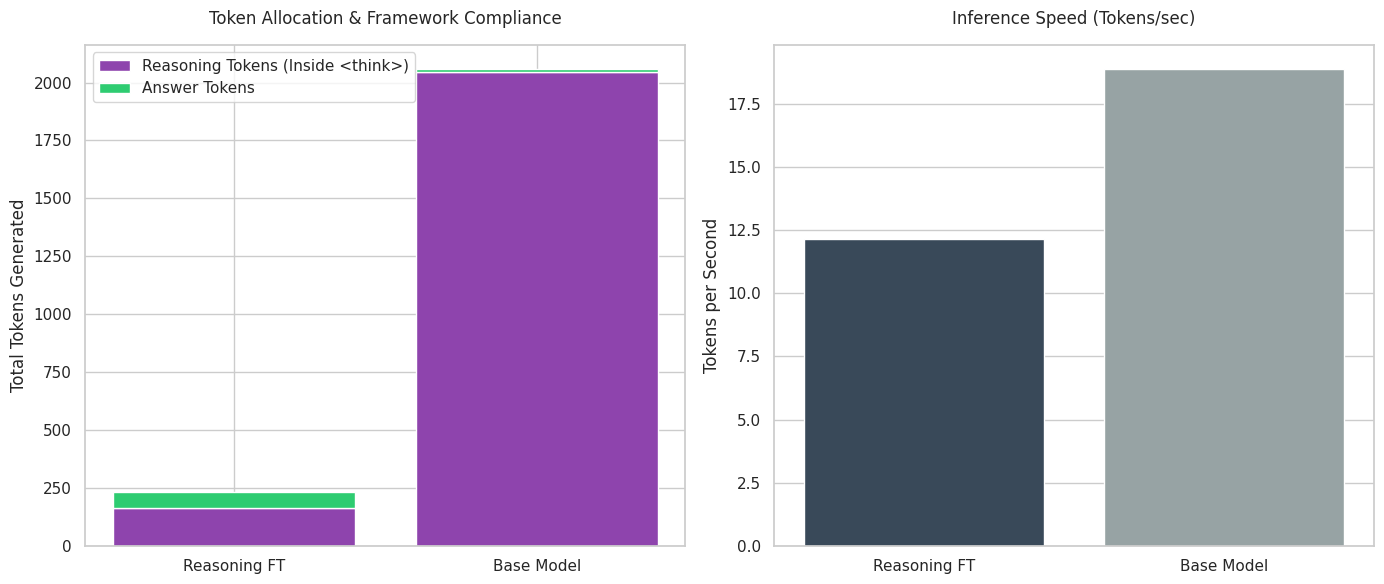

In [6]:
# The Test Problem
test_prompt = input("enter your input")

print("Running Srikri7 Fine-Tune...")
res_ft = generate_adversarial(m1, t1, test_prompt)

print("Running Qwen Base...")
res_base = generate_adversarial(m2, t2, test_prompt)

# --- 1. Terminal Output Dump ---
for name, res in [("Srikri7 Reasoning FT", res_ft), ("Qwen Base Model", res_base)]:
    print("\n" + "="*90)
    print(f"🧠 MODEL: {name}")
    print("="*90)
    print("THINKING PROCESS:")
    print("-" * 40)
    print(res['reasoning'])
    print("-" * 40)
    print("FINAL ANSWER:")
    print(res['answer'])

# --- 2. Telemetry Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Reasoning FT', 'Base Model']

# Stacked Bar: Did the model waste tokens or use them efficiently?
axes[0].bar(models, [res_ft['reasoning_toks'], res_base['reasoning_toks']], label='Reasoning Tokens (Inside <think>)', color='#8e44ad')
axes[0].bar(models, [res_ft['answer_toks'], res_base['answer_toks']],
            bottom=[res_ft['reasoning_toks'], res_base['reasoning_toks']],
            label='Answer Tokens', color='#2ecc71')
axes[0].set_title('Token Allocation & Framework Compliance', fontsize=12, pad=15)
axes[0].set_ylabel('Total Tokens Generated')
axes[0].legend()

# Bar: Inference Speed
sns.barplot(x=models, y=[res_ft['tps'], res_base['tps']], ax=axes[1], palette=['#34495e', '#95a5a6'])
axes[1].set_title('Inference Speed (Tokens/sec)', fontsize=12, pad=15)
axes[1].set_ylabel('Tokens per Second')

plt.tight_layout()
plt.show()

FIXING SHORTCUT THINKING

In [7]:
import torch
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def generate_universal_scratchpad(model, tokenizer, prompt):
    # THE UNIVERSAL STATE-TRACKING PROMPT
    system_instruction = (
        "You are a deterministic logic engine. You have limited working memory and MUST use a visual scratchpad to track state.\n\n"
        "To solve the user's problem, you must strictly follow this framework inside your <think> tags:\n\n"
        "STEP 1: INITIALIZATION\n"
        "Identify the core dimensions of the puzzle (e.g., entities, slots, properties) and design a text-based grid, table, or list to track them.\n\n"
        "STEP 2: THE DEDUCTION LOOP\n"
        "You must repeat the following block for EVERY single logical step until the puzzle is solved. Do not combine steps. Do not skip ahead.\n"
        "---LOOP START---\n"
        "CURRENT STATE:\n[Draw your current tracking grid here. You must redraw it completely every time.]\n\n"
        "TARGET FACT:\n[Quote exactly one fact/rule from the prompt you are currently applying]\n\n"
        "DEDUCTION:\n[Explain what this fact tells you and exactly how it updates the state]\n"
        "---LOOP END---\n\n"
        "You may only exit the loop and close the </think> tag when the state is 100% complete.\n"
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": prompt}
    ]

    try:
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        text = f"System: {system_instruction}\nUser: {prompt}\nAssistant: "

    # Force the model into the Initialization phase immediately
    if not text.endswith("<think>\n"):
         text += "<think>\nSTEP 1: INITIALIZATION\n"

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3072, # Increased significantly because redrawing the grid takes tokens
            temperature=0.6,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time

    generated_ids = outputs[0][len(inputs['input_ids'][0]):]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Advanced Forgiving Parser
    reasoning_text = full_response
    final_answer = ""

    if "<answer>" in full_response:
        parts = full_response.split('<answer>')
        reasoning_text = parts[0].replace('</think>', '').strip()
        final_answer = parts[1].replace('</answer>', '').strip()
    elif "</think>" in full_response:
        parts = full_response.split('</think>')
        reasoning_text = parts[0].strip()
        final_answer = parts[1].strip()
    else:
        final_answer = "[FRAMEWORK FAILURE: Token limit reached or model lost formatting]"

    reasoning_tokens = len(tokenizer.encode(reasoning_text)) if reasoning_text else 0
    answer_tokens = len(tokenizer.encode(final_answer)) if final_answer else 0
    total_tokens = reasoning_tokens + answer_tokens
    tps = total_tokens / gen_time if gen_time > 0 else 0

    return reasoning_text, final_answer, reasoning_tokens, answer_tokens, total_tokens, tps

Running Srikri7 Fine-Tune (Universal Scratchpad)...
Running Qwen Base Model (Universal Scratchpad)...

🧠 MODEL: Srikri7 Reasoning FT
THINKING PROCESS:
--------------------------------------------------
Identify the core dimensions of the puzzle (e.g., entities, slots, properties) and design a text-based grid, table, or list to track them.

Entities:
- Vaults: 1, 2, 3, 4
- Keys: Gold, Silver, Bronze, Iron
- Data Types: Financial, Medical, Military, Identity
- Encryption Protocols: AES, RSA, ChaCha, ECC

Grid:
Vault 1: Key=?, Data=?, Protocol=?
Vault 2: Key=?, Data=?, Protocol=?
Vault 3: Key=?, Data=?, Protocol=?
Vault 4: Key=?, Data=?, Protocol=?

Target Facts:
1. The Gold key opens the vault containing Medical data.
2. Vault 2 exclusively uses AES encryption.
3. The Iron key is used for the vault immediately to the right of the vault using RSA encryption.
4. Military data is stored in Vault 4.
5. The Silver key utilizes ChaCha encryption.
6. Financial data is stored immediately to the 

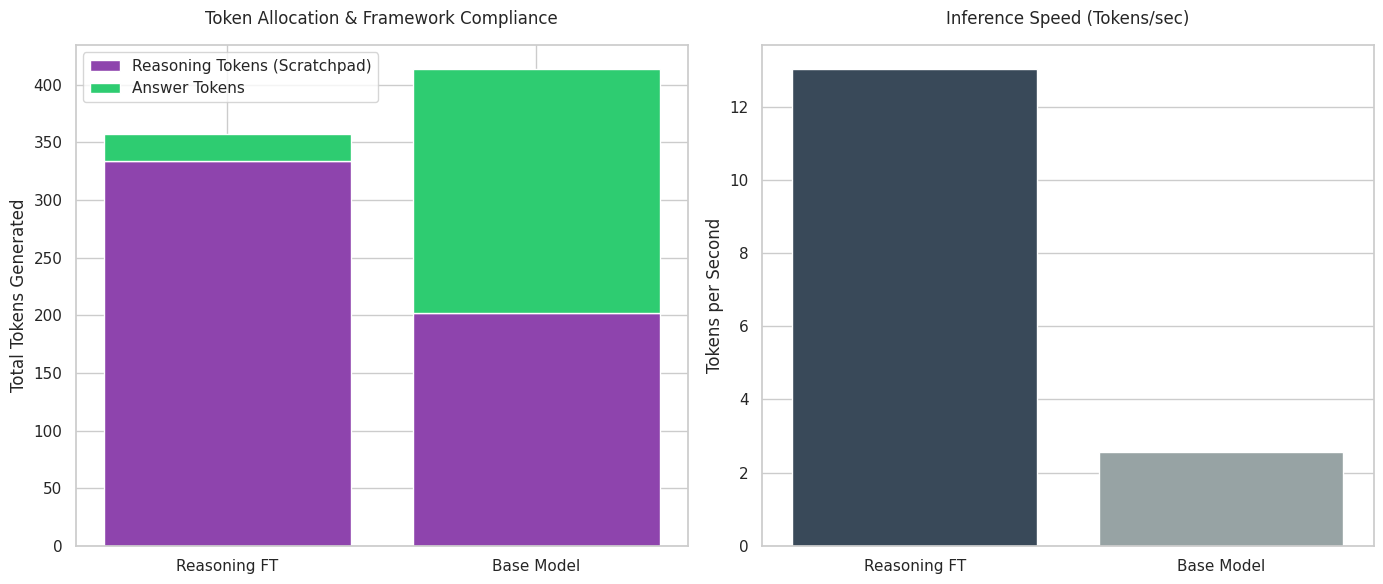

In [9]:
# The Test Problem: The Cryptographic Vaults
test_prompt = (
    "You are auditing 4 highly secure data vaults arranged in a row (Vault 1 to Vault 4, left to right). "
    "Each vault uses a different Key (Gold, Silver, Bronze, Iron), holds a different Data Type (Financial, Medical, Military, Identity), "
    "and utilizes a different Encryption Protocol (AES, RSA, ChaCha, ECC). "
    "Using the following facts, deduce the exact Key, Data Type, and Encryption for all 4 Vaults:\n\n"
    "1. The Gold key opens the vault containing Medical data.\n"
    "2. Vault 2 exclusively uses AES encryption.\n"
    "3. The Iron key is used for the vault immediately to the right of the vault using RSA encryption.\n"
    "4. Military data is stored in Vault 4.\n"
    "5. The Silver key utilizes ChaCha encryption.\n"
    "6. Financial data is stored immediately to the left of the vault opened by the Bronze key.\n"
    "7. Vault 1 uses the Silver key.\n"
    "8. ECC encryption is used for Identity data.\n\n"
    "Question 1: Which vault holds the Financial data?\n"
    "Question 2: What Encryption Protocol does the Bronze key use?\n"
    "Provide your final answers wrapped in <answer></answer> tags."
)

print("Running Srikri7 Fine-Tune (Universal Scratchpad)...")
r_ft, a_ft, rt_ft, at_ft, tot_ft, tps_ft = generate_universal_scratchpad(m1, t1, test_prompt)

print("Running Qwen Base Model (Universal Scratchpad)...")
r_base, a_base, rt_base, at_base, tot_base, tps_base = generate_universal_scratchpad(m2, t2, test_prompt)

# --- 1. Terminal Output Dump ---
for name, r_text, a_text in [
    ("Srikri7 Reasoning FT", r_ft, a_ft),
    ("Qwen Base Model", r_base, a_base)
]:
    print("\n" + "="*100)
    print(f"🧠 MODEL: {name}")
    print("="*100)
    print("THINKING PROCESS:")
    print("-" * 50)
    print(r_text)
    print("-" * 50)
    print("FINAL ANSWER:")
    print(a_text)

# --- 2. Telemetry Visualization ---
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Reasoning FT', 'Base Model']

# Stacked Bar: Token Allocation
axes[0].bar(models, [rt_ft, rt_base], label='Reasoning Tokens (Scratchpad)', color='#8e44ad')
axes[0].bar(models, [at_ft, at_base], bottom=[rt_ft, rt_base], label='Answer Tokens', color='#2ecc71')
axes[0].set_title('Token Allocation & Framework Compliance', fontsize=12, pad=15)
axes[0].set_ylabel('Total Tokens Generated')
axes[0].legend()

# Bar: Inference Speed
sns.barplot(x=models, y=[tps_ft, tps_base], hue=models, ax=axes[1], palette=['#34495e', '#95a5a6'], legend=False)
axes[1].set_title('Inference Speed (Tokens/sec)', fontsize=12, pad=15)
axes[1].set_ylabel('Tokens per Second')

plt.tight_layout()
plt.show()

Running Srikri7 Fine-Tune (Sequential CoT)...
Running Qwen Base Model (Sequential CoT)...

🧠 MODEL: Srikri7 Reasoning FT
THINKING PROCESS:
--------------------------------------------------
- There are 4 vaults: Vault 1, Vault 2, Vault 3, Vault 4 (left to right).
- Each vault has a unique Key (Gold, Silver, Bronze, Iron).
- Each vault has a unique Data Type (Financial, Medical, Military, Identity).
- Each vault has a unique Encryption Protocol (AES, RSA, ChaCha, ECC).
- Facts:
  1. Gold key opens the vault containing Medical data.
  2. Vault 2 exclusively uses AES encryption.
  3. The Iron key is used for the vault immediately to the right of the vault using RSA encryption.
  4. Military data is stored in Vault 4.
  5. The Silver key utilizes ChaCha encryption.
  6. Financial data is stored immediately to the left of the vault opened by the Bronze key.
  7. Vault 1 uses the Silver key.
  8. ECC encryption is used for Identity data.

2. DEDUCTIONS:
- From Fact 7: Vault 1 uses the Silver

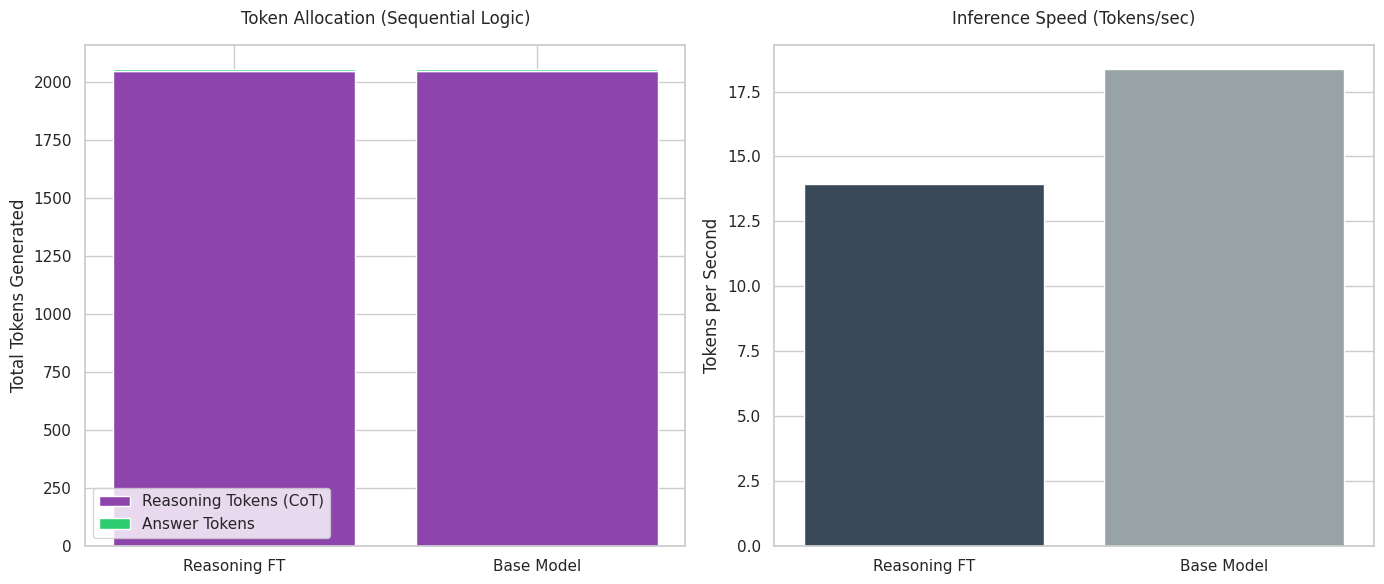

In [10]:
import torch
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def generate_sequential_cot(model, tokenizer, prompt):
    # 2B-OPTIMIZED SYSTEM PROMPT
    # We abandon the programmatic loops and bracket replacements.
    # Instead, we force a natural language progression: List Knowns -> Make Connections -> Conclude.
    system_instruction = (
        "You are a precise analytical agent. You must solve the problem by thinking step-by-step. "
        "Do not guess. Follow this exact reasoning structure inside your <think> tags:\n\n"
        "1. KNOWNS: List out the absolute facts provided in the prompt.\n"
        "2. DEDUCTIONS: Combine the facts one by one to uncover new information. Explain your logic clearly (e.g., 'Since X is true, Y must be Z').\n"
        "3. FINAL STATE: Summarize the completely solved scenario.\n\n"
        "After closing the </think> tag, provide your final answers wrapped in <answer></answer> tags."
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": prompt}
    ]

    try:
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        text = f"System: {system_instruction}\nUser: {prompt}\nAssistant: <think>\n1. KNOWNS:\n"

    # Force the model to start the structured CoT
    if not text.endswith("<think>\n"):
         text += "<think>\n1. KNOWNS:\n"

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2048,
            temperature=0.5, # Slightly lower temperature for deterministic logic paths
            repetition_penalty=1.05, # Light penalty to prevent stuttering
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time

    generated_ids = outputs[0][len(inputs['input_ids'][0]):]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Parser
    reasoning_text = full_response
    final_answer = ""

    if "<answer>" in full_response:
        parts = full_response.split('<answer>')
        reasoning_text = parts[0].replace('</think>', '').strip()
        final_answer = parts[1].replace('</answer>', '').strip()
    elif "</think>" in full_response:
        parts = full_response.split('</think>')
        reasoning_text = parts[0].strip()
        final_answer = parts[1].strip()
    else:
        final_answer = "[FRAMEWORK FAILURE: Model lost formatting]"

    reasoning_tokens = len(tokenizer.encode(reasoning_text)) if reasoning_text else 0
    answer_tokens = len(tokenizer.encode(final_answer)) if final_answer else 0
    total_tokens = reasoning_tokens + answer_tokens
    tps = total_tokens / gen_time if gen_time > 0 else 0

    return reasoning_text, final_answer, reasoning_tokens, answer_tokens, total_tokens, tps

# --- The Test Problem ---
test_prompt = (
    "You are auditing 4 highly secure data vaults arranged in a row (Vault 1 to Vault 4, left to right). "
    "Each vault uses a different Key (Gold, Silver, Bronze, Iron), holds a different Data Type (Financial, Medical, Military, Identity), "
    "and utilizes a different Encryption Protocol (AES, RSA, ChaCha, ECC). "
    "Using the following facts, deduce the exact Key, Data Type, and Encryption for all 4 Vaults:\n\n"
    "1. The Gold key opens the vault containing Medical data.\n"
    "2. Vault 2 exclusively uses AES encryption.\n"
    "3. The Iron key is used for the vault immediately to the right of the vault using RSA encryption.\n"
    "4. Military data is stored in Vault 4.\n"
    "5. The Silver key utilizes ChaCha encryption.\n"
    "6. Financial data is stored immediately to the left of the vault opened by the Bronze key.\n"
    "7. Vault 1 uses the Silver key.\n"
    "8. ECC encryption is used for Identity data.\n\n"
    "Question 1: Which vault holds the Financial data?\n"
    "Question 2: What Encryption Protocol does the Bronze key use?\n"
    "Provide your final answers wrapped in <answer></answer> tags."
)

print("Running Srikri7 Fine-Tune (Sequential CoT)...")
r_ft, a_ft, rt_ft, at_ft, tot_ft, tps_ft = generate_sequential_cot(m1, t1, test_prompt)

print("Running Qwen Base Model (Sequential CoT)...")
r_base, a_base, rt_base, at_base, tot_base, tps_base = generate_sequential_cot(m2, t2, test_prompt)

# --- Terminal Output Dump ---
for name, r_text, a_text in [
    ("Srikri7 Reasoning FT", r_ft, a_ft),
    ("Qwen Base Model", r_base, a_base)
]:
    print("\n" + "="*100)
    print(f"🧠 MODEL: {name}")
    print("="*100)
    print("THINKING PROCESS:")
    print("-" * 50)
    print(r_text)
    print("-" * 50)
    print("FINAL ANSWER:")
    print(a_text)

# --- Telemetry Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Reasoning FT', 'Base Model']

axes[0].bar(models, [rt_ft, rt_base], label='Reasoning Tokens (CoT)', color='#8e44ad')
axes[0].bar(models, [at_ft, at_base], bottom=[rt_ft, rt_base], label='Answer Tokens', color='#2ecc71')
axes[0].set_title('Token Allocation (Sequential Logic)', fontsize=12, pad=15)
axes[0].set_ylabel('Total Tokens Generated')
axes[0].legend()

sns.barplot(x=models, y=[tps_ft, tps_base], hue=models, ax=axes[1], palette=['#34495e', '#95a5a6'], legend=False)
axes[1].set_title('Inference Speed (Tokens/sec)', fontsize=12, pad=15)
axes[1].set_ylabel('Tokens per Second')

plt.tight_layout()
plt.show()

In [11]:
import torch

def get_raw_thoughts(model, tokenizer, prompt):
    # Dead simple system prompt. No forcing, no tricks.
    messages = [
        {"role": "system", "content": "You are a logical problem solver. Think step-by-step."},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1500,
            temperature=0.3, # Low temp for deterministic logic
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # Slice off the prompt and return strictly the model's generation
    generated_ids = outputs[0][len(inputs['input_ids'][0]):]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)


# --- The Test Problem ---
# A classic trick question that requires actual sequential logic to beat the intuitive trap.
test_prompt = (
    "A snail is at the bottom of a 20-foot well. Each day, it climbs up 5 feet, "
    "but at night, it slips down 4 feet. How many days will it take for the snail "
    "to reach the top of the well?"
)

print("Running Srikri7 Fine-Tune...")
raw_ft = get_raw_thoughts(m1, t1, test_prompt)

print("Running Qwen Base Model...")
raw_base = get_raw_thoughts(m2, t2, test_prompt)

# --- The Raw Text Dump ---
print("\n" + "="*80)
print("🧠 MODEL: Srikri7 Reasoning FT")
print("="*80)
print(raw_ft)

print("\n" + "="*80)
print("🧠 MODEL: Qwen Base Model")
print("="*80)
print(raw_base)

Running Srikri7 Fine-Tune...
Running Qwen Base Model...

🧠 MODEL: Srikri7 Reasoning FT
The snail will reach the top of the well on the 8th day.

🧠 MODEL: Qwen Base Model
The snail climbs 5 feet during the day and slips 4 feet at night, so each full day it makes a net gain of 1 foot. However, on the last day, once the snail reaches or exceeds the top, it doesn't slip back.

Let's calculate:

- After 15 days, the snail has climbed 15 feet (15 days × 1 foot/day).
- On day 16, it climbs 5 feet during the day. Since it starts at 15 feet, it reaches 20 feet during the day and reaches the top.
- It does not slip back at night because it has already reached the top.

Thus, it takes **16 days** for the snail to reach the top of the well.



Running Srikri7 Fine-Tune (Clean CoT)...
Running Qwen Base Model (Clean CoT)...

🧠 MODEL: Srikri7 Reasoning FT
THINKING PROCESS:
----------------------------------------
Here's a thinking process that leads to the solution:

1.  **Analyze the Problem:**
    *   Initial position: Bottom of a 20-foot well (0 feet).
    *   Climbing speed: +5 feet per day.
    *   Slipping speed: -4 feet per night (after climbing).
    *   Goal: Reach the top (20 feet).
    *   Condition: The snail stops slipping once it reaches or exceeds the top during the day.

2.  **Determine the Net Gain per Day:**
    *   During the day, the snail gains 5 feet.
    *   At night, the snail loses 4 feet.
    *   Net gain = $5 - 4 = 1$ foot per full day cycle (day + night).

3.  **Calculate the "Effective" Progress per Day:**
    *   If we just look at the net progress, the snail is gaining 1 foot every 24 hours.
    *   However, the snail can escape the well before the night slip happens if its height increases by 5 f

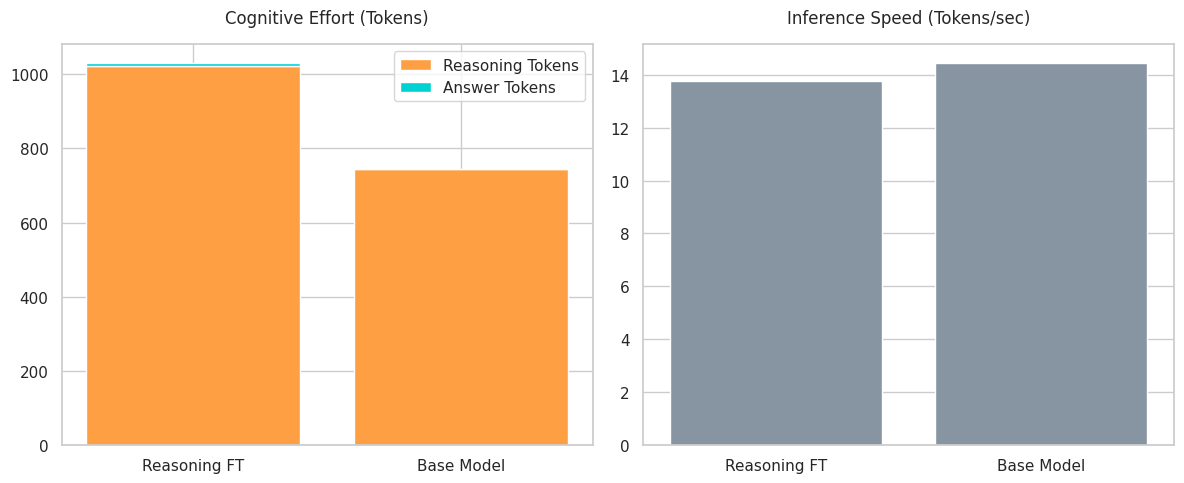

In [12]:
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def generate_clean_cot(model, tokenizer, prompt):
    # A clean, standard reasoning prompt. No loops, no complex structures.
    # Just "think step by step" and use the tags.
    system_instruction = (
        "You are a logical problem solver. You must think step-by-step to arrive at the correct solution.\n"
        "1. Put all of your internal reasoning inside <think> and </think> tags.\n"
        "2. Put your final, concise answer inside <answer> and </answer> tags."
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": prompt}
    ]

    # Apply chat template with a fallback
    try:
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        text = f"System: {system_instruction}\nUser: {prompt}\nAssistant: <think>\n"

    if not text.endswith("<think>\n"):
         text += "<think>\n"

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024, # 1024 is plenty for a simple linear puzzle
            temperature=0.3, # Low temp for strictly logical outputs
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time

    generated_ids = outputs[0][len(inputs['input_ids'][0]):]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Clean Parser
    reasoning_text = full_response
    final_answer = "[Missing <answer> tag]"

    if "</think>" in full_response:
        parts = full_response.split('</think>')
        reasoning_text = parts[0].strip()
        remainder = parts[1].strip()

        if "<answer>" in remainder and "</answer>" in remainder:
            ans_start = remainder.find("<answer>") + len("<answer>")
            ans_end = remainder.find("</answer>")
            final_answer = remainder[ans_start:ans_end].strip()
        else:
            final_answer = remainder.strip() if remainder else "[No final answer provided]"

    reasoning_tokens = len(tokenizer.encode(reasoning_text))
    answer_tokens = len(tokenizer.encode(final_answer))
    total_tokens = reasoning_tokens + answer_tokens
    tps = total_tokens / gen_time if gen_time > 0 else 0

    return reasoning_text, final_answer, reasoning_tokens, answer_tokens, tps

# --- The Simple Logic Trap ---
test_prompt = (
    "A snail is at the bottom of a 20-foot well. "
    "Every day, it climbs up 5 feet, but at night, while sleeping, it slips down 4 feet. "
    "How many days will it take for the snail to reach the top of the well?"
)

print("Running Srikri7 Fine-Tune (Clean CoT)...")
r_ft, a_ft, rt_ft, at_ft, tps_ft = generate_clean_cot(m1, t1, test_prompt)

print("Running Qwen Base Model (Clean CoT)...")
r_base, a_base, rt_base, at_base, tps_base = generate_clean_cot(m2, t2, test_prompt)

# --- Terminal Output Dump ---
for name, r_text, a_text in [
    ("Srikri7 Reasoning FT", r_ft, a_ft),
    ("Qwen Base Model", r_base, a_base)
]:
    print("\n" + "="*80)
    print(f"🧠 MODEL: {name}")
    print("="*80)
    print("THINKING PROCESS:")
    print("-" * 40)
    print(r_text)
    print("-" * 40)
    print("FINAL ANSWER:")
    print(a_text)

# --- Telemetry Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models = ['Reasoning FT', 'Base Model']

axes[0].bar(models, [rt_ft, rt_base], label='Reasoning Tokens', color='#FF9F43')
axes[0].bar(models, [at_ft, at_base], bottom=[rt_ft, rt_base], label='Answer Tokens', color='#00D2D3')
axes[0].set_title('Cognitive Effort (Tokens)', fontsize=12, pad=15)
axes[0].legend()

sns.barplot(x=models, y=[tps_ft, tps_base], hue=models, ax=axes[1], palette=['#8395A7', '#8395A7'], legend=False)
axes[1].set_title('Inference Speed (Tokens/sec)', fontsize=12, pad=15)

plt.tight_layout()
plt.show()

In [13]:
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

def generate_efficiency_benchmark(model, tokenizer, prompt):
    system_instruction = (
        "You are an expert mathematician. Solve the problem using the most efficient mathematical formula possible. "
        "Do not simulate step-by-step unless absolutely necessary.\n"
        "1. Put your mathematical reasoning inside <think> and </think> tags.\n"
        "2. Put your final number inside <answer> and </answer> tags."
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": prompt}
    ]

    try:
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        text = f"System: {system_instruction}\nUser: {prompt}\nAssistant: <think>\n"

    if not text.endswith("<think>\n"):
         text += "<think>\n"

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2048, # High limit to let inefficient models trap themselves
            temperature=0.1,     # Extreme low temp to force strict math
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time

    generated_ids = outputs[0][len(inputs['input_ids'][0]):]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True)

    reasoning_text = full_response
    final_answer = "[FAILED TO EXTRACT]"

    if "</think>" in full_response:
        parts = full_response.split('</think>')
        reasoning_text = parts[0].strip()
        remainder = parts[1].strip()

        if "<answer>" in remainder and "</answer>" in remainder:
            ans_start = remainder.find("<answer>") + len("<answer>")
            ans_end = remainder.find("</answer>")
            final_answer = remainder[ans_start:ans_end].strip()
        else:
            final_answer = remainder.strip()

    reasoning_tokens = len(tokenizer.encode(reasoning_text))
    answer_tokens = len(tokenizer.encode(final_answer))
    total_tokens = reasoning_tokens + answer_tokens
    tps = total_tokens / gen_time if gen_time > 0 else 0

    return reasoning_text, final_answer, total_tokens, gen_time, tps

# --- THE SCALING TRAP PROMPT ---
test_prompt = (
    "A deep-sea rover is at the bottom of a 10,000-meter oceanic trench. "
    "Every day, its battery allows it to climb exactly 500 meters up the trench wall. "
    "Every night, it powers down, and the ocean currents push it back down 400 meters. "
    "Exactly how many days will it take for the rover to reach the top of the 10,000-meter trench?"
)

print("Running Srikri7 Fine-Tune (Efficiency Test)...")
r_ft, a_ft, tok_ft, time_ft, tps_ft = generate_efficiency_benchmark(m1, t1, test_prompt)

print("Running Qwen Base Model (Efficiency Test)...")
r_base, a_base, tok_base, time_base, tps_base = generate_efficiency_benchmark(m2, t2, test_prompt)

# --- Terminal Output Dump ---
print("\n" + "="*80)
print(f"RESULTS: Srikri7 Fine-Tune")
print("="*80)
print(f"Final Answer: {a_ft}")
print(f"Tokens Wasted (Cost): {tok_ft} tokens")
print(f"Time to Output: {time_ft:.2f} seconds")

print("\n" + "="*80)
print(f"RESULTS: Qwen Base Model")
print("="*80)
print(f"Final Answer: {a_base}")
print(f"Tokens Wasted (Cost): {tok_base} tokens")
print(f"Time to Output: {time_base:.2f} seconds")

# --- Efficiency Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Srikri7 FT', 'Qwen Base']

# Plot 1: The Token Tax (Lower is Better)
sns.barplot(x=models, y=[tok_ft, tok_base], ax=axes[0], palette=['#e74c3c', '#3498db'])
axes[0].set_title('Computational Cost (Total Tokens Used) ↓', fontsize=14, pad=15)
axes[0].set_ylabel('Tokens')
for i, v in enumerate([tok_ft, tok_base]):
    axes[0].text(i, v + 20, str(v), color='black', ha='center', fontweight='bold')

# Plot 2: Time to Solve (Lower is Better)
sns.barplot(x=models, y=[time_ft, time_base], ax=axes[1], palette=['#e74c3c', '#3498db'])
axes[1].set_title('Total Latency (Seconds to Solve) ↓', fontsize=14, pad=15)
axes[1].set_ylabel('Seconds')
for i, v in enumerate([time_ft, time_base]):
    axes[1].text(i, v + 0.5, f"{v:.2f}s", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Running Srikri7 Fine-Tune (Efficiency Test)...


KeyboardInterrupt: 

Running Srikri7 Fine-Tune (Efficiency Test)...
Running Qwen Base Model (Efficiency Test)...

RESULTS: Srikri7 Fine-Tune
Final Answer: 100
Tokens Wasted (Cost): 824 tokens
Time to Output: 83.83 seconds

RESULTS: Qwen Base Model
Final Answer: [FAILED TO EXTRACT]
Tokens Wasted (Cost): 2054 tokens
Time to Output: 108.21 seconds


/tmp/ipykernel_2437/2778467795.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=[tok_ft, tok_base], ax=axes[0], palette=['#e74c3c', '#3498db'])
/tmp/ipykernel_2437/2778467795.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=[time_ft, time_base], ax=axes[1], palette=['#e74c3c', '#3498db'])


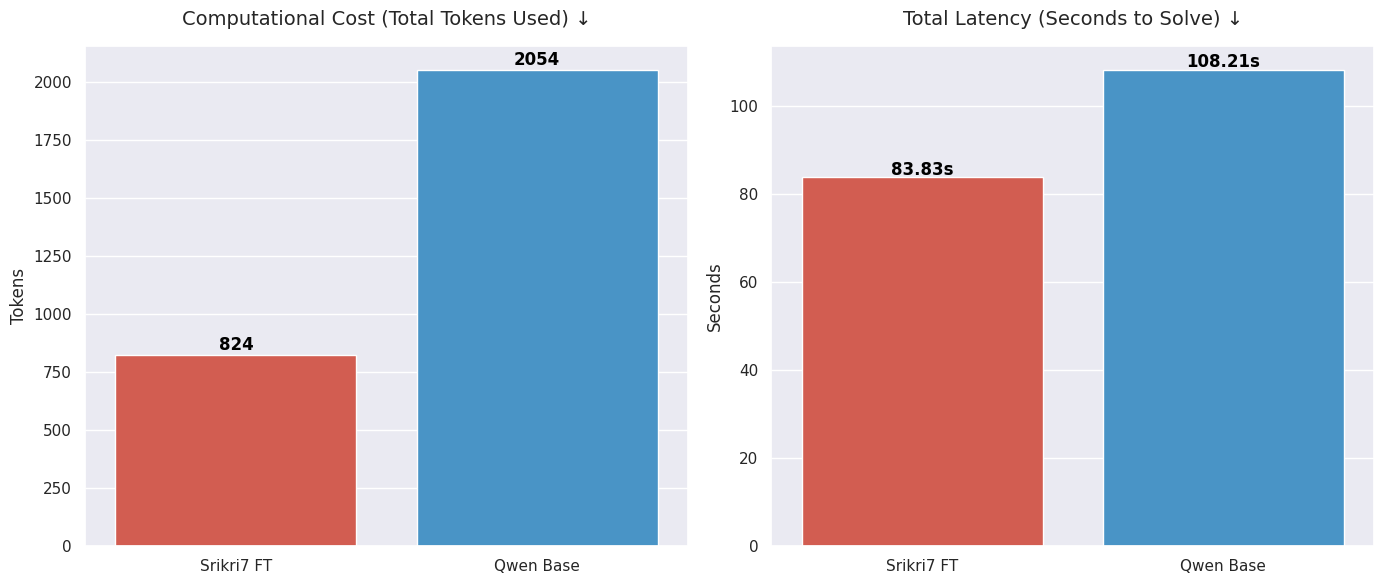

In [14]:
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

def generate_efficiency_benchmark(model, tokenizer, prompt):
    system_instruction = (
        "You are an expert mathematician. Solve the problem using the most efficient mathematical formula possible. "
        "Do not simulate step-by-step unless absolutely necessary.\n"
        "1. Put your mathematical reasoning inside <think> and </think> tags.\n"
        "2. Put your final number inside <answer> and </answer> tags."
    )

    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": prompt}
    ]

    try:
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    except Exception:
        text = f"System: {system_instruction}\nUser: {prompt}\nAssistant: <think>\n"

    if not text.endswith("<think>\n"):
         text += "<think>\n"

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2048, # High limit to let inefficient models trap themselves
            temperature=0.1,     # Extreme low temp to force strict math
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time

    generated_ids = outputs[0][len(inputs['input_ids'][0]):]
    full_response = tokenizer.decode(generated_ids, skip_special_tokens=True)

    reasoning_text = full_response
    final_answer = "[FAILED TO EXTRACT]"

    if "</think>" in full_response:
        parts = full_response.split('</think>')
        reasoning_text = parts[0].strip()
        remainder = parts[1].strip()

        if "<answer>" in remainder and "</answer>" in remainder:
            ans_start = remainder.find("<answer>") + len("<answer>")
            ans_end = remainder.find("</answer>")
            final_answer = remainder[ans_start:ans_end].strip()
        else:
            final_answer = remainder.strip()

    reasoning_tokens = len(tokenizer.encode(reasoning_text))
    answer_tokens = len(tokenizer.encode(final_answer))
    total_tokens = reasoning_tokens + answer_tokens
    tps = total_tokens / gen_time if gen_time > 0 else 0

    return reasoning_text, final_answer, total_tokens, gen_time, tps

# --- THE SCALING TRAP PROMPT ---
test_prompt = (
    "A deep-sea rover is at the bottom of a 10,000-meter oceanic trench. "
    "Every day, its battery allows it to climb exactly 500 meters up the trench wall. "
    "Every night, it powers down, and the ocean currents push it back down 400 meters. "
    "Exactly how many days will it take for the rover to reach the top of the 10,000-meter trench?"
)

print("Running Srikri7 Fine-Tune (Efficiency Test)...")
r_ft, a_ft, tok_ft, time_ft, tps_ft = generate_efficiency_benchmark(m1, t1, test_prompt)

print("Running Qwen Base Model (Efficiency Test)...")
r_base, a_base, tok_base, time_base, tps_base = generate_efficiency_benchmark(m2, t2, test_prompt)

# --- Terminal Output Dump ---
print("\n" + "="*80)
print(f"RESULTS: Srikri7 Fine-Tune")
print("="*80)
print(f"Final Answer: {a_ft}")
print(f"Tokens Wasted (Cost): {tok_ft} tokens")
print(f"Time to Output: {time_ft:.2f} seconds")

print("\n" + "="*80)
print(f"RESULTS: Qwen Base Model")
print("="*80)
print(f"Final Answer: {a_base}")
print(f"Tokens Wasted (Cost): {tok_base} tokens")
print(f"Time to Output: {time_base:.2f} seconds")

# --- Efficiency Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = ['Srikri7 FT', 'Qwen Base']

# Plot 1: The Token Tax (Lower is Better)
sns.barplot(x=models, y=[tok_ft, tok_base], ax=axes[0], palette=['#e74c3c', '#3498db'])
axes[0].set_title('Computational Cost (Total Tokens Used) ↓', fontsize=14, pad=15)
axes[0].set_ylabel('Tokens')
for i, v in enumerate([tok_ft, tok_base]):
    axes[0].text(i, v + 20, str(v), color='black', ha='center', fontweight='bold')

# Plot 2: Time to Solve (Lower is Better)
sns.barplot(x=models, y=[time_ft, time_base], ax=axes[1], palette=['#e74c3c', '#3498db'])
axes[1].set_title('Total Latency (Seconds to Solve) ↓', fontsize=14, pad=15)
axes[1].set_ylabel('Seconds')
for i, v in enumerate([time_ft, time_base]):
    axes[1].text(i, v + 0.5, f"{v:.2f}s", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Benchmarking Srikri7 FT...
Benchmarking Qwen Base...

🧠 MODEL: Srikri7 Reasoning FT
THINKING PROCESS:
----------------------------------------
The user wants me to solve a puzzle: "You have a 5-liter jug, a 3-liter jug, and an unlimited supply of water. You need to measure exactly 4 liters of water. How do you do it?"

I need to find a sequence of steps that allows me to measure exactly 4 liters of water using the given jugs.

Let's think about this problem. I have two jugs with capacities 5L and 3L. I can fill them from an infinite source of water. I can also empty them into a sink or discard the water.

Goal: Measure exactly 4 liters.

Possible approach:
- Fill the 5L jug
- Pour from 5L jug into 3L jug until 3L jug is full
- The 5L jug now has 2L left
- Empty the 3L jug
- Pour the 2L from 5L jug into 3L jug
- Fill the 5L jug again
- Pour from 5L jug into 3L jug until 3L jug is full (it will take 1L more)
- The 5L jug now has 4L left
- This 4L is what we want!

Let me verify this:
1. 

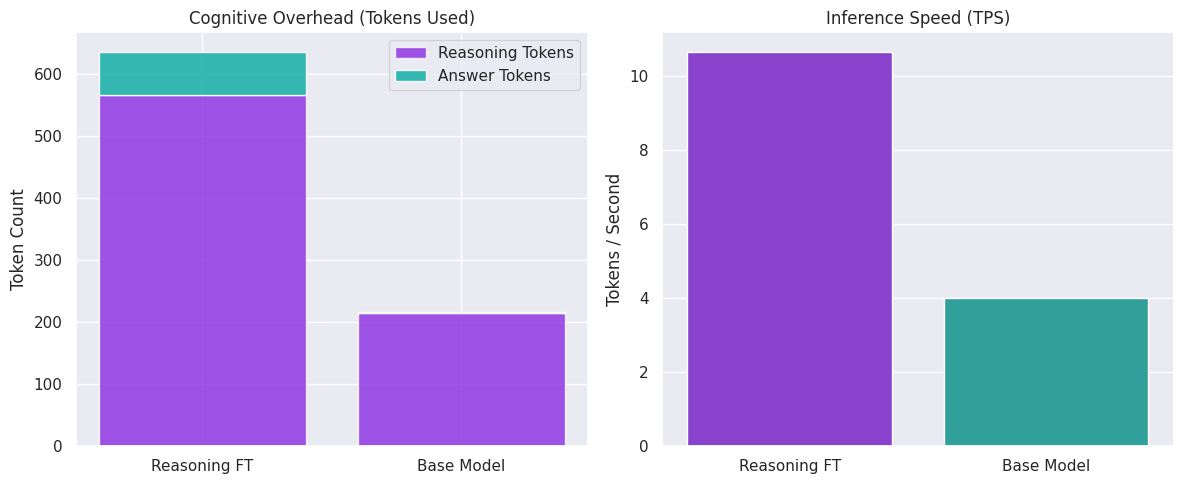

In [15]:
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

def evaluate_and_display(model, tokenizer, prompt):
    system_instruction = (
        "You are a precise logical solver. Think step-by-step.\n"
        "1. Put all reasoning inside <think> and </think> tags.\n"
        "2. Put your final answer inside <answer> and </answer> tags."
    )

    # Fast prompt construction
    text = f"<|im_start|>system\n{system_instruction}<|im_end|>\n<|im_start|>user\n{prompt}<|im_end|>\n<|im_start|>assistant\n<think>\n"
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.1, # Extremely low variance for strict logic
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time

    generated_text = tokenizer.decode(outputs[0][len(inputs['input_ids'][0]):], skip_special_tokens=True)

    # Terse Parser that ensures we capture the thoughts
    reasoning = generated_text
    answer = "[Missing <answer> tag]"

    if "</think>" in generated_text:
        parts = generated_text.split("</think>")
        reasoning = parts[0].strip()
        remainder = parts[1].strip()
        if "<answer>" in remainder and "</answer>" in remainder:
            ans_start = remainder.find("<answer>") + len("<answer>")
            ans_end = remainder.find("</answer>")
            answer = remainder[ans_start:ans_end].strip()
        else:
            answer = remainder.replace("<answer>", "").strip() if remainder else answer

    r_toks = len(tokenizer.encode(reasoning))
    a_toks = len(tokenizer.encode(answer))
    total_toks = r_toks + a_toks
    tps = total_toks / gen_time if gen_time > 0 else 0

    return {
        "reasoning": reasoning,
        "answer": answer,
        "r_toks": r_toks,
        "a_toks": a_toks,
        "total_toks": total_toks,
        "time": gen_time,
        "tps": tps
    }

# --- The Logic Prompt ---
puzzle = (
    "You have a 5-liter jug, a 3-liter jug, and an unlimited supply of water. "
    "You need to measure exactly 4 liters of water. How do you do it?"
)

print("Benchmarking Srikri7 FT...")
ft_data = evaluate_and_display(m1, t1, puzzle)

print("Benchmarking Qwen Base...")
base_data = evaluate_and_display(m2, t2, puzzle)

# --- Full Transparency Output Display ---
for name, data in [("Srikri7 Reasoning FT", ft_data), ("Qwen Base Model", base_data)]:
    print(f"\n{'='*80}\n🧠 MODEL: {name}\n{'='*80}")
    print("THINKING PROCESS:")
    print("-" * 40)
    print(data['reasoning'])
    print("-" * 40)
    print("FINAL ANSWER:")
    print(data['answer'])
    print("-" * 40)
    print(f"⏱️ METRICS: {data['total_toks']} tokens generated in {data['time']:.2f}s ({data['tps']:.2f} tok/s)")

# --- Efficiency Visuals (Fixed Seaborn Warnings) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
models = ['Reasoning FT', 'Base Model']
colors = ['#8A2BE2', '#20B2AA']

# Stacked Bar: Cognitive Overhead
ax1.bar(models, [ft_data['r_toks'], base_data['r_toks']], label='Reasoning Tokens', color=colors[0], alpha=0.8)
ax1.bar(models, [ft_data['a_toks'], base_data['a_toks']], bottom=[ft_data['r_toks'], base_data['r_toks']], label='Answer Tokens', color=colors[1], alpha=0.9)
ax1.set_title('Cognitive Overhead (Tokens Used)')
ax1.set_ylabel('Token Count')
ax1.legend()

# Bar: Throughput
sns.barplot(x=models, y=[ft_data['tps'], base_data['tps']], hue=models, ax=ax2, palette=colors, legend=False)
ax2.set_title('Inference Speed (TPS)')
ax2.set_ylabel('Tokens / Second')

plt.tight_layout()
plt.show()